In [1]:
# load default packages
import pandas as pd
import matplotlib.pyplot as plt

# load decision tree model & helper functions
from decision_tree_classify import *
from utils import *

## 1. Weather dataset

In [2]:
# load data
df = pd.read_csv("data/tennis.txt")
df = df.drop(['Day'], axis = 1)

In [3]:
# split train & test set
y_train, X_train, y_test, X_test = train_test_split(df, 0.2, 'Play')

In [4]:
#  fit the decision trees model
cls_weather = Decision_Tree_Classification(max_depth = 3, min_split_val=2)
cls_weather.fit(X_train, y_train)
y_pred = cls_weather.class_prediction(X_test)

In [5]:
accuracy(y_pred, y_test)

1.0

In [6]:
cls_weather.print_tree(df)


⊛ Humidity = High ?
-> left (true): 
   ⊛ Outlook = Sunny ?
   -> left (true): No
   -> right (false): 
      ⊛ Wind = Strong ?
      -> left (true): 
         ⊛ Outlook = Overcast ?
         -> left (true): Yes
         -> right (false): No
      -> right (false): Yes
-> right (false): 
   ⊛ Outlook = Rain ?
   -> left (true): 
      ⊛ Wind = Strong ?
      -> left (true): No
      -> right (false): Yes
   -> right (false): Yes


## 2. Car evaluation dataset

In [7]:
# load data
df2 = pd.read_csv("data/car_evaluation.csv", header = None)
df2.columns =['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

In [8]:
# convert to 2 classes (binary classfication)
df2['class'] = df2['class'].apply(lambda x: "0" if x == "unacc" else "1").astype('int')

In [9]:
y_train2, X_train2, y_test2, X_test2 = train_test_split(df2, 0.2, 'class')

In [10]:
# fit car dataset to decision trees
pred_car = Decision_Tree_Classification(max_depth=10, min_split_val=2)


In [11]:
DT_cross_validation(X_train2, y_train2, 10, 2)

,Accuracy,True Positive,True Negative,False Positive,False Negative,Precision,Recall,F-score
0,0.790614,26,193,0,58,1.000000,0.309524,0.472727
1,0.830325,82,148,45,2,0.645669,0.976190,0.777251
2,0.804348,53,169,23,31,0.697368,0.630952,0.662500
3,0.844203,50,183,9,34,0.847458,0.595238,0.699301
4,0.992754,84,190,2,0,0.976744,1.000000,0.988235


#### Min split value

In [12]:
eva_list2 = []
for i in range(2,12,1):

    e2 = DT_cross_validation(X_train2, y_train2, 20, i)

    eva_list2.append([e2['Accuracy'].mean(), e2['Accuracy'].std(), e2['Precision'].mean(), e2['Recall'].mean(), e2['F-score'].mean()])
df_e2 = pd.DataFrame(eva_list2,columns=['mean_acc','std_acc', 'mean_precision', 'mean_recall', 'mean_f1_score'])
df_e2['min_split'] = pd.Series(range(2,12,1))
df_e2

,mean_acc,std_acc,mean_precision,mean_recall,mean_f1_score,min_split
0,0.852449,0.081210,0.832996,0.704762,0.720421,2
1,0.853173,0.080688,0.835308,0.702381,0.720836,3
2,0.850999,0.078085,0.829008,0.702381,0.717705,4
3,0.848825,0.079840,0.826521,0.695238,0.712593,5
4,0.848825,0.079840,0.826521,0.695238,0.712593,6
5,0.845935,0.082535,0.824670,0.688095,0.703223,7
6,0.845935,0.082535,0.824670,0.688095,0.703223,8
7,0.845935,0.082535,0.824670,0.688095,0.703223,9
8,0.846657,0.081824,0.824670,0.690476,0.706130,10
9,0.845932,0.073904,0.817037,0.702381,0.708442,11


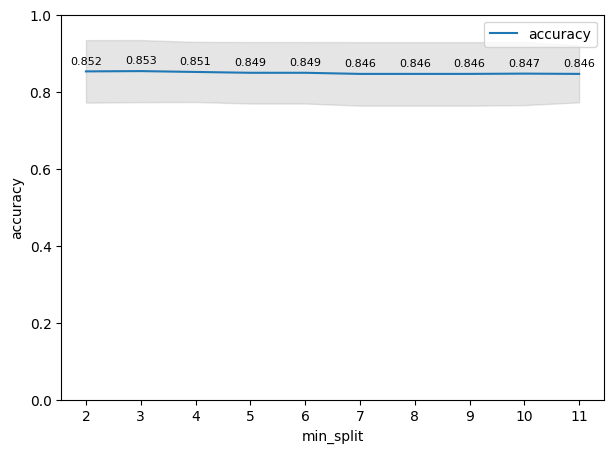

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
df_e2.plot('min_split', 'mean_acc', ax= ax, label = 'accuracy')
# df_e2.plot('min_split', 'mean_precision', ax= ax, label = 'precision')
# df_e2.plot('min_split', 'mean_recall', ax= ax, label = 'recall')
# df_e.reset_index().plot('min_split', 'mean', 'o', ax= ax)
plt.fill_between(df_e2['min_split'], df_e2['mean_acc'] - df_e2['std_acc'], df_e2['mean_acc'] + df_e2['std_acc'],
                 color='gray', alpha=0.2) 
ax.set(ylim=(0,1), xticks = range(2,12,1), ylabel='accuracy')
# ax.get_legend().remove()
for i, v in zip(df_e2['min_split'], round(df_e2['mean_acc'], 3)):
    ax.text(i, v+.02, f"{v}", fontsize=8, ha="center")
plt.show()

#### Max depth

In [14]:
eva_list = []
# std_list = []
for i in range(3,13,1):

    # predcar = Decision_Tree_Classification(max_depth=i, min_split_val=2)

    e = DT_cross_validation(X_train2, y_train2,i,2)

    eva_list.append([e['Accuracy'].mean(), e['Accuracy'].std(), e['Precision'].mean(), e['Recall'].mean(), e['F-score'].mean()])
df_e = pd.DataFrame(eva_list,columns=['mean_acc','std_acc', 'mean_precision', 'mean_recall', 'mean_f1_score'])
df_e['max_depth'] = pd.Series(range(3,13,1))


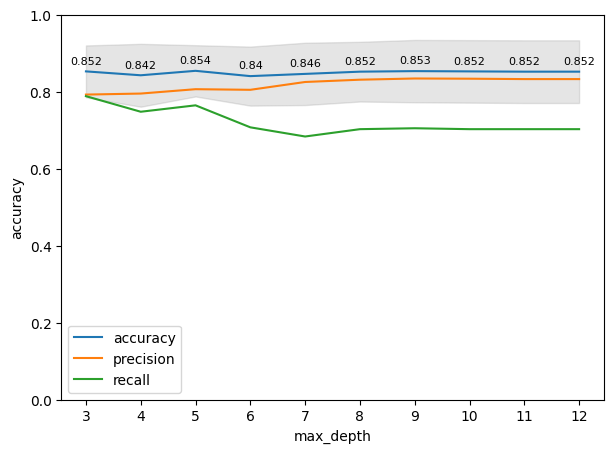

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
df_e.plot('max_depth', 'mean_acc', ax= ax, label = 'accuracy')
df_e.plot('max_depth', 'mean_precision', ax= ax, label = 'precision')
df_e.plot('max_depth', 'mean_recall', ax= ax, label = 'recall')
# df_e.reset_index().plot('max_depth', 'mean', 'o', ax= ax)
plt.fill_between(df_e['max_depth'], df_e['mean_acc'] - df_e['std_acc'], df_e['mean_acc'] + df_e['std_acc'],
                 color='gray', alpha=0.2) 
ax.set(ylim=(0,1), xticks = range(3,13,1), ylabel='accuracy')
# ax.get_legend().remove()
for i, v in zip(df_e['max_depth'], round(df_e['mean_acc'], 3)):
    ax.text(i, v+.02, f"{v}", fontsize=8, ha="center")
plt.show()

In [17]:
predcar_bestdepth = Decision_Tree_Classification(max_depth = 5, min_split_val=2)
predcar_bestdepth.fit(X_train2, y_train2)
y_pred2 = predcar_bestdepth.class_prediction(X_test2)

In [18]:
accuracy(y_pred2, y_test2)

0.9393063583815029

In [19]:
# Confusion matrix
pd.crosstab(pd.Series(y_pred2), pd.Series(y_test2), rownames=['Actual'], colnames=['Predicted'], margins=True)

Predicted,0,1,All
Actual,,,
0,238,11,249
1,10,87,97
All,248,98,346


#### Gini vs Entropy

In [20]:
predcar_gini = Decision_Tree_Classification(max_depth = 5, min_split_val=2)
predcar_gini.fit(X_train2, y_train2)
y_pred2g = predcar_gini.class_prediction(X_test2)

In [21]:
accuracy(y_pred2g, y_test2)

0.9393063583815029

In [22]:
# Confusion matrix
pd.crosstab(pd.Series(y_pred2g), pd.Series(y_test2), rownames=['Actual'], colnames=['Predicted'], margins=True)

Predicted,0,1,All
Actual,,,
0,238,11,249
1,10,87,97
All,248,98,346
